# Type 2 Diabetes Mellitus Prevalence, Risk Factors, and Trajectory 

### Libraries

In [110]:
import pandas as pd
from matplotlib import pyplot as plt
import json
import numpy as np
import geopandas as gpd
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [20]:
df = pd.read_csv("../data/IHME-GBD_2023_DATA-e860792f-1/IHME-GBD_2023_DATA-e860792f-1.csv")

In [21]:
age_order = [
    "<5 years", "5-9 years", "10-14 years", "15-19 years",
    "20-24 years", "25-29 years", "30-34 years", "35-39 years",
    "40-44 years", "45-49 years", "50-54 years", "55-59 years",
    "60-64 years", "65-69 years", "70-74 years", "75-79 years",
    "80-84 years", "85-89 years", "90-94 years", "95+ years"
]

df["age_name"] = pd.Categorical(df["age_name"], categories=age_order, ordered=True)
df = df.sort_values("age_name")

In [22]:
df.head()

,measure_id,measure_name,location_id,location_name,sex_id,sex_name,age_id,age_name,cause_id,cause_name,metric_id,metric_name,year,val,upper,lower
0,5,Prevalence,36,Kazakhstan,3,Both,1,<5 years,976,Diabetes mellitus type 2,1,Number,2023,0.0,0.0,0.0
4769,5,Prevalence,163,India,3,Both,1,<5 years,976,Diabetes mellitus type 2,2,Percent,2023,0.0,0.0,0.0
4768,5,Prevalence,163,India,3,Both,1,<5 years,976,Diabetes mellitus type 2,1,Number,2023,0.0,0.0,0.0
4757,5,Prevalence,171,Democratic Republic of the Congo,3,Both,1,<5 years,976,Diabetes mellitus type 2,2,Percent,2023,0.0,0.0,0.0
4756,5,Prevalence,171,Democratic Republic of the Congo,3,Both,1,<5 years,976,Diabetes mellitus type 2,1,Number,2023,0.0,0.0,0.0


In [23]:
with open("../data/regions.json", "r", encoding="utf-8") as f:
    regions = json.load(f)
    
country_to_region = {
    country: region
    for region, countries in regions.items()
    for country in countries
}


In [24]:
df["region"] = [country_to_region[acountry] for acountry in df["location_name"].to_list()]

In [25]:
percent_df = df[df["metric_name"] == "Percent"]

In [26]:
percent_df.head()

,measure_id,measure_name,location_id,location_name,sex_id,sex_name,age_id,age_name,cause_id,cause_name,metric_id,metric_name,year,val,upper,lower,region
4769,5,Prevalence,163,India,3,Both,1,<5 years,976,Diabetes mellitus type 2,2,Percent,2023,0.0,0.0,0.0,South Asia
4757,5,Prevalence,171,Democratic Republic of the Congo,3,Both,1,<5 years,976,Diabetes mellitus type 2,2,Percent,2023,0.0,0.0,0.0,Central Sub-Saharan Africa
4739,5,Prevalence,162,Bhutan,3,Both,1,<5 years,976,Diabetes mellitus type 2,2,Percent,2023,0.0,0.0,0.0,South Asia
4725,5,Prevalence,160,Afghanistan,3,Both,1,<5 years,976,Diabetes mellitus type 2,2,Percent,2023,0.0,0.0,0.0,North Africa and Middle East
1593,5,Prevalence,74,Andorra,3,Both,1,<5 years,976,Diabetes mellitus type 2,2,Percent,2023,0.0,0.0,0.0,Western Europe


In [27]:
col_to_keep = ["region", "age_name", "val", "upper", "lower"]
percent_grouped_df = percent_df[col_to_keep].groupby(["region", "age_name"]).sum("val").reset_index()

/tmp/ipykernel_31825/2891395920.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  percent_grouped_df = percent_df[col_to_keep].groupby(["region", "age_name"]).sum("val").reset_index()


In [28]:
percent_grouped_df

,region,age_name,val,upper,lower
0,Andean Latin America,<5 years,0.000000,0.000000,0.000000
1,Andean Latin America,5-9 years,0.000000,0.000000,0.000000
2,Andean Latin America,10-14 years,0.000000,0.000000,0.000000
3,Andean Latin America,15-19 years,0.015922,0.020571,0.012122
4,Andean Latin America,20-24 years,0.027429,0.034107,0.022016
...,...,...,...,...,...
415,Western Sub-Saharan Africa,75-79 years,3.995975,4.476195,3.607470
416,Western Sub-Saharan Africa,80-84 years,3.736225,4.190660,3.360258
417,Western Sub-Saharan Africa,85-89 years,3.259732,3.682464,2.887376
418,Western Sub-Saharan Africa,90-94 years,2.637202,3.033483,2.281962


In [29]:
percent_grouped_df['region'].unique()

array(['Andean Latin America', 'Australasia', 'Caribbean', 'Central Asia',
       'Central Europe', 'Central Latin America',
       'Central Sub-Saharan Africa', 'East Asia', 'Eastern Europe',
       'Eastern Sub-Saharan Africa', 'High-income Asia Pacific',
       'High-income North America', 'North Africa and Middle East',
       'Oceania', 'South Asia', 'Southeast Asia',
       'Southern Latin America', 'Southern Sub-Saharan Africa',
       'Tropical Latin America', 'Western Europe',
       'Western Sub-Saharan Africa'], dtype=object)

In [30]:
def age_midpoint(age):
    if age.startswith("<"):
        return 2.5
    if "+" in age:
        return 97.5
    start, end = age.split("-")
    return (int(start) + int(end.split()[0])) / 2

percent_grouped_df["age_mid"] = percent_grouped_df["age_name"].apply(age_midpoint)

## Exploratory analysis Age and Gender
### Age is one of the risk factors for Type 2 Diabetes Mellitus

[Age is linked to type 2 diabetes](https://pmc.ncbi.nlm.nih.gov/articles/PMC9843502/)

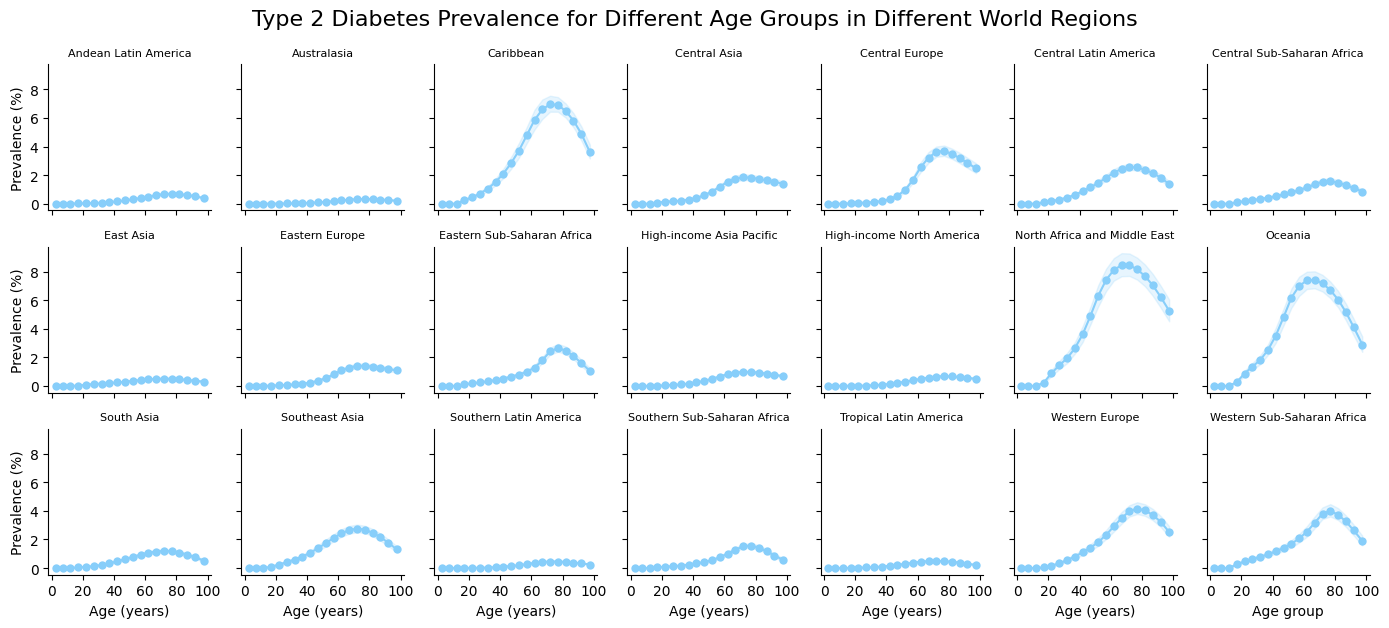

In [33]:
regions = percent_grouped_df['region'].unique()
n = len(regions)
nrows=3
ncols=7

label_xaxis = list(range((nrows * ncols - ncols), nrows * ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*2, nrows*2), sharex=True, sharey=True)

axes = axes.flatten()

count = 0

for ax, region in zip(axes, regions):


    region_df = percent_grouped_df[percent_grouped_df['region'] == region]
    
    ax.plot(region_df['age_mid'], region_df['val'], label='Mean', marker='o', markeredgewidth=0, color="lightskyblue")
    ax.fill_between(
        region_df['age_mid'],
        region_df['lower'],
        region_df['upper'],
        color='lightskyblue', alpha=0.2
    )


    col = count % ncols
    if col == 0:
        ax.set_ylabel("Prevalence (%)")
    else:
        ax.set_ylabel("")
        ax.tick_params(axis="y", labelleft=False)


    if count in label_xaxis:
        ax.set_xlabel("Age (years)")
    else:
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelleft=False)
    count += 1
    

    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.set_title(region, fontsize=8)
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


plt.xlabel("Age group")
plt.tight_layout()
fig.suptitle(
    "Type 2 Diabetes Prevalence for Different Age Groups in Different World Regions",
    y=1.04,
    fontsize=16)
plt.show()

### Age-standardised

I still need to get age standardised-dataset

https://towardsdatascience.com/a-beginners-guide-to-create-a-cloropleth-map-in-python-using-geopandas-and-matplotlib-9cc4175ab630/
https://r2.datahub.io/clvyjaryy0000la0cxieg4o8o/main/raw/data/countries.geojson

In [34]:
url = "https://r2.datahub.io/clvyjaryy0000la0cxieg4o8o/main/raw/data/countries.geojson"
map_df = gpd.read_file(url)
map_df = map_df[map_df["name"] != "Antarctica"]
# Check the GeoDataframe
map_df.head(2)

,name,ISO3166-1-Alpha-3,ISO3166-1-Alpha-2,geometry
0,Indonesia,IDN,ID,"MULTIPOLYGON (((117.70361 4.16342, 117.70361 4..."
1,Malaysia,MYS,MY,"MULTIPOLYGON (((117.70361 4.16342, 117.69711 4..."


<Axes: >

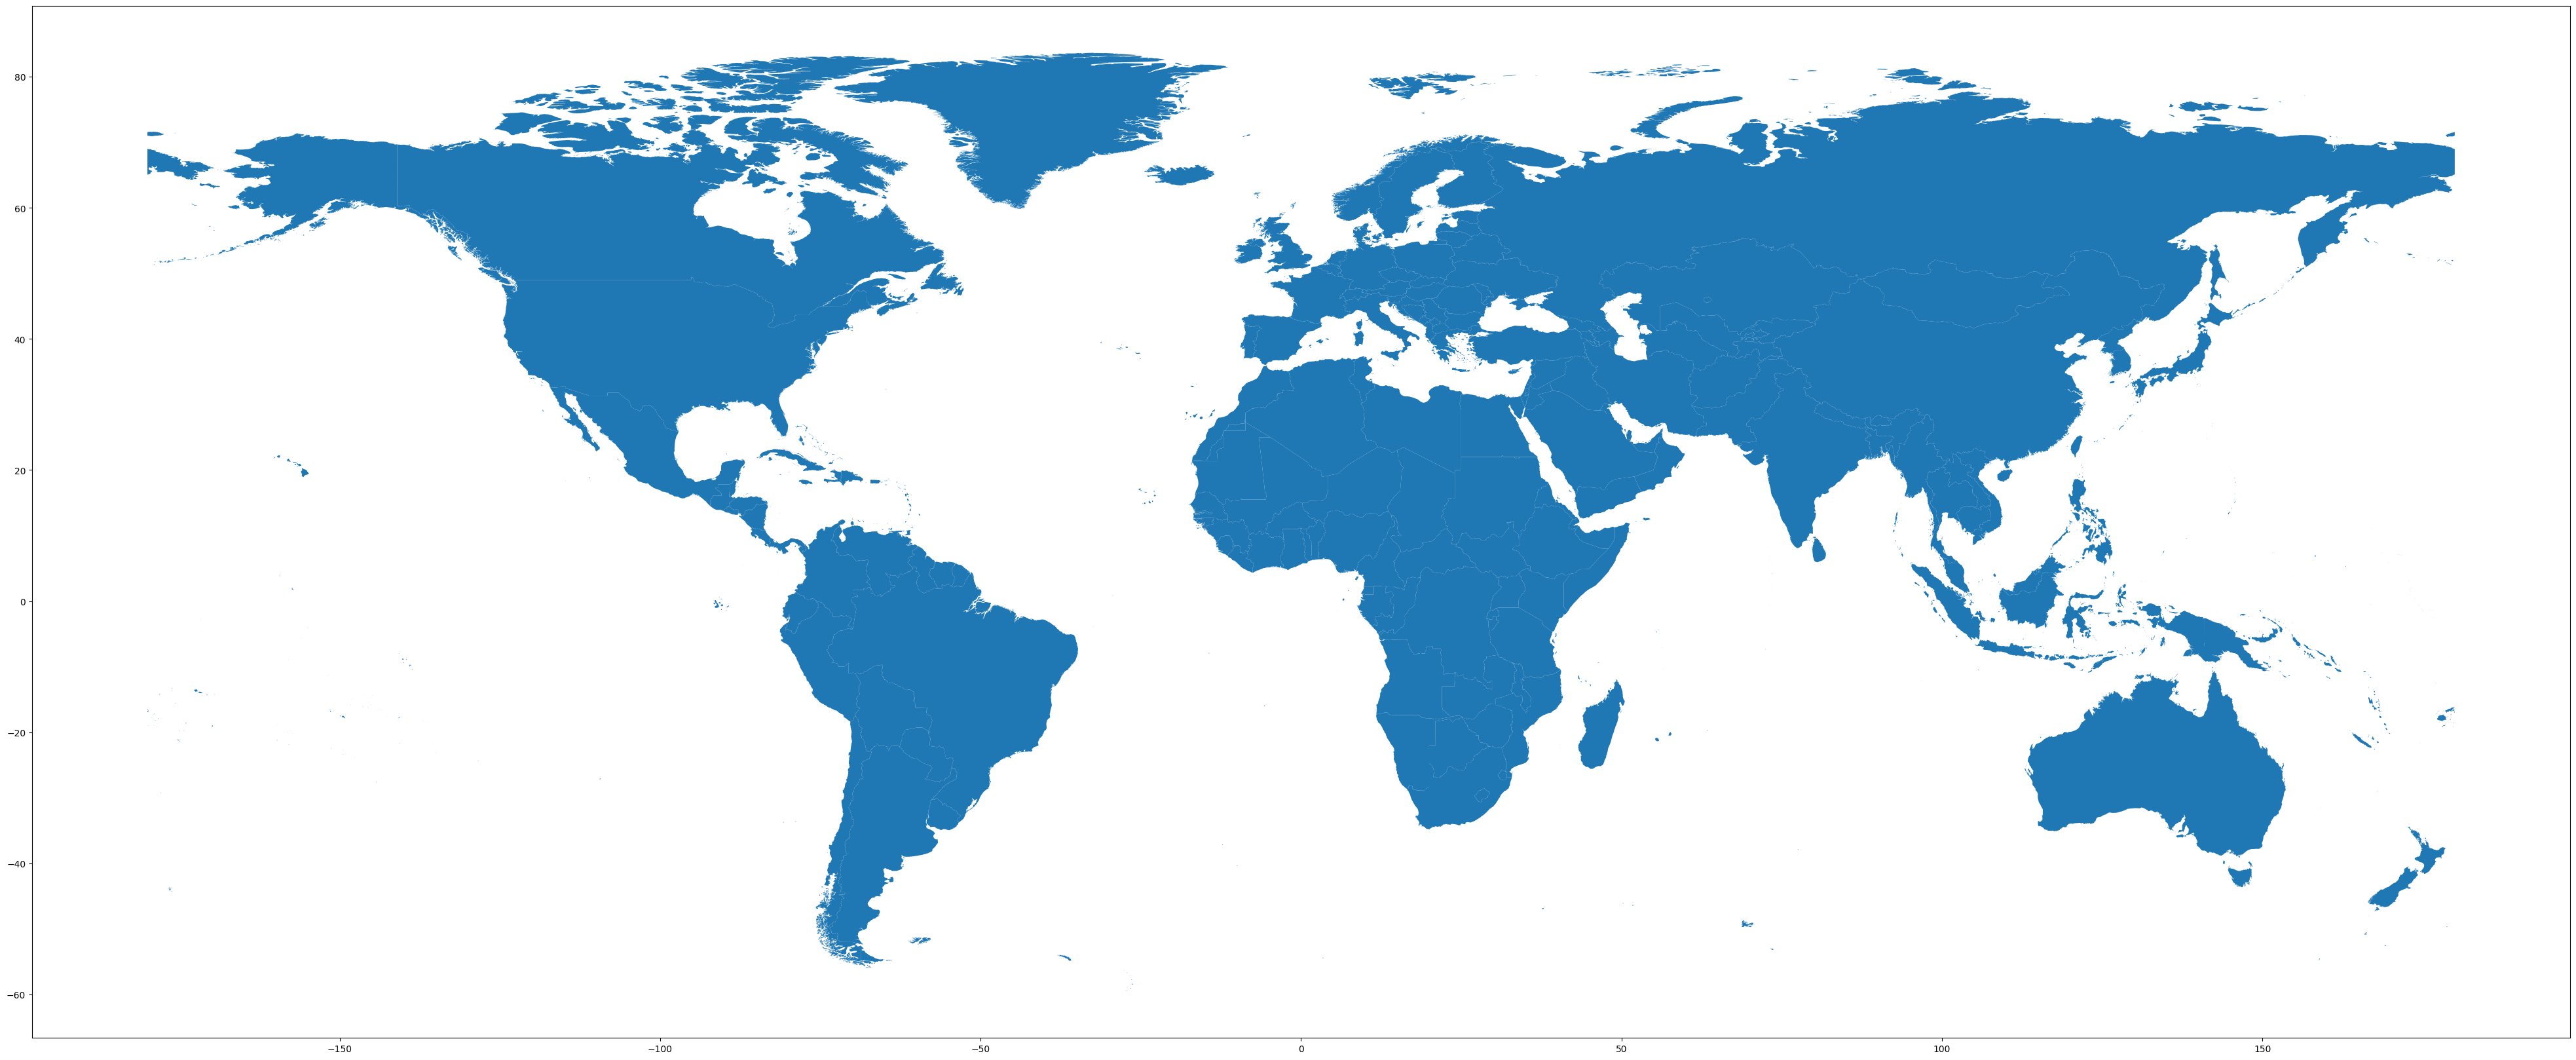

In [35]:
plt.rcParams['figure.figsize'] = [50, 70] #height, width
map_df.plot()

In [36]:
absent = []
for country in map_df.name:
    if country not in percent_df.location_name.unique():
        absent.append(country)
absent_df = pd.DataFrame(absent)
absent_df

,0
0,Bolivia
1,Dhekelia Sovereign Base Area
2,Syria
3,Somaliland
4,South Korea
...,...
69,Macao S.A.R
70,Ashmore and Cartier Islands
71,Bajo Nuevo Bank (Petrel Is.)
72,Serranilla Bank


I manually curated the absent_df.csv 

In [46]:
country_map = {
    "Bolivia": "Bolivia (Plurinational State of)",
    "Dhekelia Sovereign Base Area": "Dhekelia Sovereign Base Area",
    "Syria": "Syrian Arab Republic",
    "Somaliland": "Somalia",
    "South Korea": "Republic of Korea",
    "North Korea": "Democratic People's Republic of Korea",
    "Western Sahara": "Western Sahara",
    "Republic of the Congo": "Democratic Republic of the Congo",
    "Saint Martin": "Saint Martin",
    "Sint Maarten": "Sint Maarten",
    "Russia": "Russian Federation",
    "Vietnam": "Viet Nam",
    "Kosovo": "Kosovo",
    "Turkey": "Türkiye",
    "Laos": "Lao P`eople's Democratic Republic",
    "Iran": "Iran (Islamic Republic of)",
    "Liechtenstein": "Liechtenstein",
    "Ivory Coast": "Côte d'Ivoire",
    "Republic of Serbia": "Serbia",
    "East Timor": "Timor-Leste",
    "Brunei": "Brunei Darussalam",
    "eSwatini": "Eswatini",
    "US Naval Base Guantanamo Bay": "US Naval Base Guantanamo Bay",
    "Brazilian Island": "Brazilian Island",
    "Moldova": "Republic of Moldova",
    "Gibraltar": "Gibraltar",
    "Venezuela": "Venezuela (Bolivarian Republic of)",
    "Hong Kong S.A.R.": "Hong Kong S.A.R.",
    "Vatican": "Vatican City",
    "Northern Cyprus": "Northern Cyprus",
    "Cyprus No Mans Area": "Cyprus No Mans Area",
    "Siachen Glacier": "Siachen Glacier",
    "Baykonur Cosmodrome": "Baykonur Cosmodrome",
    "Akrotiri Sovereign Base Area": "Akrotiri Sovereign Base Area",
    "Southern Patagonian Ice Field": "Southern Patagonian Ice Field",
    "Bir Tawil": "Bir Tawil",
    "New Caledonia": "New Caledonia",
    "Curaçao": "Curaçao",
    "Aruba": "Aruba",
    "The Bahamas": "Bahamas",
    "Turks and Caicos Islands": "Turks and Caicos Islands",
    "Saint Pierre and Miquelon": "Saint Pierre and Miquelon",
    "Pitcairn Islands": "Pitcairn Islands",
    "French Polynesia": "French Polynesia",
    "French Southern and Antarctic Lands": "French Southern and Antarctic Lands",
    "United States Minor Outlying Islands": "United States Minor Outlying Islands",
    "Montserrat": "Montserrat",
    "Saint Barthelemy": "Saint Barthelemy",
    "Anguilla": "Anguilla",
    "British Virgin Islands": "British Virgin Islands",
    "Cayman Islands": "Cayman Islands",
    "Heard Island and McDonald Islands": "Heard Island and McDonald Islands",
    "Saint Helena": "Saint Helena",
    "São Tomé and Principe": "Sao Tome and Principe",
    "Jersey": "Jersey",
    "Guernsey": "Guernsey",
    "Isle of Man": "Isle of Man",
    "Aland": "Aland",
    "Faroe Islands": "Faroe Islands",
    "Indian Ocean Territories": "Indian Ocean Territories",
    "British Indian Ocean Territory": "British Indian Ocean Territory",
    "Norfolk Island": "Norfolk Island",
    "Wallis and Futuna": "Wallis and Futuna",
    "Federated States of Micronesia": "Micronesia (Federated States of)",
    "South Georgia and the Islands": "South Georgia and the Islands",
    "Falkland Islands": "Falkland Islands",
    "Coral Sea Islands": "Coral Sea Islands",
    "Spratly Islands": "Spratly Islands",
    "Clipperton Island": "Clipperton Island",
    "Macao S.A.R": "Macao S.A.R",
    "Ashmore and Cartier Islands": "Ashmore and Cartier Islands",
    "Bajo Nuevo Bank (Petrel Is.)": "Bajo Nuevo Bank (Petrel Is.)",
    "Serranilla Bank": "Serranilla Bank",
    "Scarborough Reef": "Scarborough Reef"}

In [49]:
map_df["country_name_GBD"] = [
    acountry if acountry in percent_df.location_name.unique()
    else country_map[acountry]
    for acountry in map_df.name
]

In [53]:
merged = map_df.merge(percent_df, left_on='country_name_GBD', right_on='location_name', how='inner')


In [54]:
merged.head()

,name,ISO3166-1-Alpha-3,ISO3166-1-Alpha-2,geometry,country_name_GBD,measure_id,measure_name,location_id,location_name,sex_id,...,age_name,cause_id,cause_name,metric_id,metric_name,year,val,upper,lower,region
0,Indonesia,IDN,ID,"MULTIPOLYGON (((117.70361 4.16342, 117.70361 4...",Indonesia,5,Prevalence,11,Indonesia,3,...,<5 years,976,Diabetes mellitus type 2,2,Percent,2023,0.000000,0.000000,0.000000,Southeast Asia
1,Indonesia,IDN,ID,"MULTIPOLYGON (((117.70361 4.16342, 117.70361 4...",Indonesia,5,Prevalence,11,Indonesia,3,...,5-9 years,976,Diabetes mellitus type 2,2,Percent,2023,0.000000,0.000000,0.000000,Southeast Asia
2,Indonesia,IDN,ID,"MULTIPOLYGON (((117.70361 4.16342, 117.70361 4...",Indonesia,5,Prevalence,11,Indonesia,3,...,10-14 years,976,Diabetes mellitus type 2,2,Percent,2023,0.000000,0.000000,0.000000,Southeast Asia
3,Indonesia,IDN,ID,"MULTIPOLYGON (((117.70361 4.16342, 117.70361 4...",Indonesia,5,Prevalence,11,Indonesia,3,...,15-19 years,976,Diabetes mellitus type 2,2,Percent,2023,0.006098,0.008298,0.004496,Southeast Asia
4,Indonesia,IDN,ID,"MULTIPOLYGON (((117.70361 4.16342, 117.70361 4...",Indonesia,5,Prevalence,11,Indonesia,3,...,20-24 years,976,Diabetes mellitus type 2,2,Percent,2023,0.014542,0.018551,0.011360,Southeast Asia


https://towardsdatascience.com/a-beginners-guide-to-create-a-cloropleth-map-in-python-using-geopandas-and-matplotlib-9cc4175ab630/
https://r2.datahub.io/clvyjaryy0000la0cxieg4o8o/main/raw/data/countries.geojson

In [91]:
data = merged.groupby(["country_name_GBD", "geometry", "region"]).mean("val").reset_index()

In [93]:
data = gpd.GeoDataFrame(data)
data.head()

,country_name_GBD,geometry,region,measure_id,location_id,sex_id,age_id,cause_id,metric_id,year,val,upper,lower
0,Afghanistan,"POLYGON ((74.54235 37.02167, 74.54742 37.01568...",North Africa and Middle East,5.0,160.0,3.0,26.2,976.0,2.0,2023.0,0.168592,0.187975,0.148988
1,Albania,"POLYGON ((20.56715 41.87318, 20.54172 41.86158...",Central Europe,5.0,43.0,3.0,26.2,976.0,2.0,2023.0,0.072587,0.083173,0.062884
2,Algeria,"POLYGON ((-4.82161 24.99506, -4.99519 25.10209...",North Africa and Middle East,5.0,139.0,3.0,26.2,976.0,2.0,2023.0,0.191705,0.214568,0.169926
3,American Samoa,"MULTIPOLYGON (((-170.59101 -14.26482, -170.576...",Oceania,5.0,298.0,3.0,26.2,976.0,2.0,2023.0,0.248907,0.276054,0.223193
4,Andorra,"POLYGON ((1.70701 42.50278, 1.6975 42.49446, 1...",Western Europe,5.0,74.0,3.0,26.2,976.0,2.0,2023.0,0.059368,0.068729,0.052142


In [185]:
data.sort_values("val", ascending=False).head(5)

,country_name_GBD,geometry,region,measure_id,location_id,sex_id,age_id,cause_id,metric_id,year,val,upper,lower
157,Saudi Arabia,"MULTIPOLYGON (((50.80787 24.74665, 50.88101 24...",North Africa and Middle East,5.0,152.0,3.0,26.2,976.0,2.0,2023.0,0.372323,0.412406,0.334885
114,Micronesia (Federated States of),"MULTIPOLYGON (((163.02605 5.34089, 163.03045 5...",Oceania,5.0,25.0,3.0,26.2,976.0,2.0,2023.0,0.305571,0.331524,0.279808
95,Kuwait,"MULTIPOLYGON (((47.94801 29.99404, 47.95509 29...",North Africa and Middle East,5.0,145.0,3.0,26.2,976.0,2.0,2023.0,0.305419,0.337780,0.273854
13,Bahrain,"MULTIPOLYGON (((50.55161 26.19424, 50.59474 26...",North Africa and Middle East,5.0,140.0,3.0,26.2,976.0,2.0,2023.0,0.296602,0.333086,0.261798
183,Trinidad and Tobago,"MULTIPOLYGON (((-61.00227 10.69937, -61.02086 ...",Caribbean,5.0,119.0,3.0,26.2,976.0,2.0,2023.0,0.284477,0.306769,0.261009


Add the plot within a plot
https://python-graph-gallery.com/how-to-add-plot-inside-plot/#:~:text=In%20practice%2C%20we%20add%20an,size%20of%20the%20smaller%20plot.

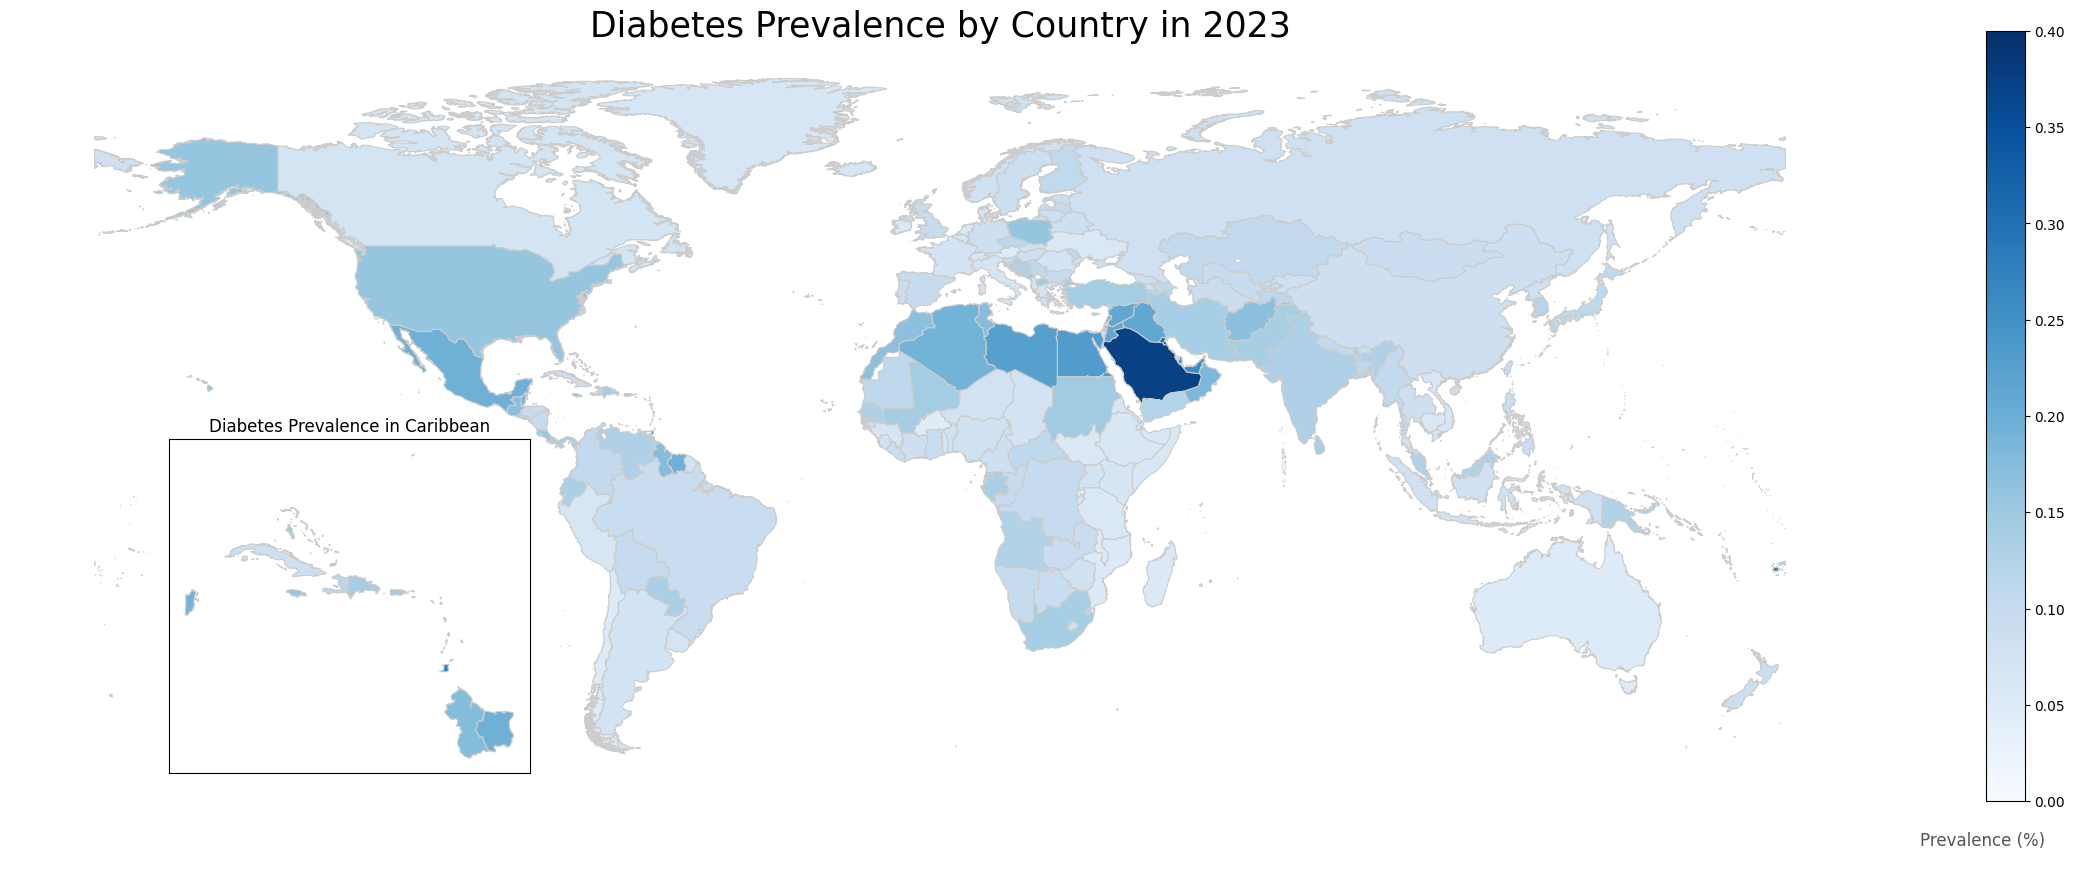

In [137]:
variable = 'val'
vmin, vmax = 0, round(data["val"].max(), 1)
fig, ax = plt.subplots(1, figsize=(30, 10))
ax.axis('off')
ax.set_title('Diabetes Prevalence by Country in 2023', fontdict={'fontsize': '25', 'fontweight' : '3'})
ax.annotate('Prevalence (%)', xy=(0.64, .04), xycoords='figure fraction', fontsize=12, color='#555555')

data.plot(column=variable, cmap='Blues', linewidth=0.8, ax=ax, edgecolor='0.8', 
            vmin=vmin, vmax=vmax)

sm = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
fig.colorbar(sm, ax=ax)

# create inset plot
sub_ax = inset_axes(
    parent_axes=ax,
    width="35%",
    height="45%",
    loc="lower left",
    borderpad=1  # padding between parent and inset axes
)
carribean_df = data[data["region"] == "Caribbean"]
carribean_df.plot(column=variable, cmap='Blues', linewidth=0.8, ax=sub_ax, edgecolor='0.8', 
            vmin=vmin, vmax=vmax)
sub_ax.set_xticks([])
sub_ax.set_yticks([])
sub_ax.set_title('Diabetes Prevalence in Caribbean', fontdict={'fontsize': '12', 'fontweight' : '3'})

plt.show()

### Scatter plot